In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Load the Data ---
try:
    # Load your vectors/heatmaps - keep original shape
    vec1 = np.load('../relevance_vit_lrp.npy')
    vec2 = np.load('../relevance_vit_crp.npy')
except FileNotFoundError:
    print("Files not found.")
    assert False

print(f"Vec1 original shape: {vec1.shape}")
print(f"Vec2 original shape: {vec2.shape}")

# Ensure they are the same shape
if vec1.shape != vec2.shape:
    raise ValueError(f"Arrays must be the same shape. Got {vec1.shape} and {vec2.shape}.")

Vec1 original shape: (1, 224, 224)
Vec2 original shape: (1, 224, 224)


In [2]:
def visualize_heat(lrp_rel, crp_rel):
    """
    Visualizes LRP and CRP relevance maps and their difference.
    Ensures that White is always Zero in the heatmaps.
    """
    difference = lrp_rel - crp_rel

    # --- Handle different array shapes: reduce to 2D for visualization ---
    # If shape is (B, C, H, W), sum channels and take first batch
    if lrp_rel.ndim == 4:
        lrp_2d = lrp_rel[0].sum(0)
        crp_2d = crp_rel[0].sum(0)
        diff_2d = difference[0].sum(0)
    # If shape is (B, H, W), take first batch
    elif lrp_rel.ndim == 3:
        lrp_2d = lrp_rel[0]
        crp_2d = crp_rel[0]
        diff_2d = difference[0]
    # If shape is (H, W), already 2D
    elif lrp_rel.ndim == 2:
        lrp_2d = lrp_rel
        crp_2d = crp_rel
        diff_2d = difference
    else:
        # 1D or other - flatten and reshape to square if possible
        lrp_rel = lrp_rel.flatten()
        crp_rel = crp_rel.flatten()
        difference = difference.flatten()
        
        size = int(np.sqrt(len(lrp_rel)))
        if size * size == len(lrp_rel):
            lrp_2d = lrp_rel.reshape(size, size)
            crp_2d = crp_rel.reshape(size, size)
            diff_2d = difference.reshape(size, size)
        else:
            print(f"Cannot reshape {len(lrp_rel)} elements to square. Skipping visualization.")
            return

    # --- Helper to get symmetric limits for "White = Zero" ---
    def get_limit(data):
        return np.max(np.abs(data))

    limit_lrp = get_limit(lrp_2d)
    limit_crp = get_limit(crp_2d)
    limit_diff = get_limit(diff_2d)

    # --- Visualize as Heatmaps ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # --- Subplot 1: LRP Heatmap ---
    # vmin/vmax set symmetrically around 0 ensures 0 is white
    im1 = axes[0].imshow(lrp_2d, cmap='RdBu_r', aspect='auto', 
                         vmin=-limit_lrp, vmax=limit_lrp)
    axes[0].set_title('Heatmap 1 (LRP)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    plt.colorbar(im1, ax=axes[0], label='Relevance')

    # --- Subplot 2: CRP Heatmap ---
    im2 = axes[1].imshow(crp_2d, cmap='RdBu_r', aspect='auto',
                         vmin=-limit_crp, vmax=limit_crp)
    axes[1].set_title('Heatmap 2 (CRP)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    plt.colorbar(im2, ax=axes[1], label='Relevance')

    # --- Subplot 3: Difference Heatmap ---
    im_diff = axes[2].imshow(diff_2d, cmap='RdBu_r', aspect='auto',
                             vmin=-limit_diff, vmax=limit_diff)
    axes[2].set_title('Difference (LRP - CRP)', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('X')
    axes[2].set_ylabel('Y')
    plt.colorbar(im_diff, ax=axes[2], label='Difference')

    # Show plot
    plt.tight_layout()
    plt.show()

    # --- Print Statistics ---
    print("\n=== Statistics ===")
    print(f"LRP  - Min: {lrp_rel.min():.6e}, Max: {lrp_rel.max():.6e}, Mean: {lrp_rel.mean():.6e}, Std: {lrp_rel.std():.6e}")
    print(f"CRP  - Min: {crp_rel.min():.6e}, Max: {crp_rel.max():.6e}, Mean: {crp_rel.mean():.6e}, Std: {crp_rel.std():.6e}")
    print(f"Diff - Min: {difference.min():.6e}, Max: {difference.max():.6e}, Mean: {difference.mean():.6e}, Std: {difference.std():.6e}")
    print(f"L1 Difference: {np.linalg.norm(difference.flatten(), ord=1):.6e}")
    print(f"L2 Difference: {np.linalg.norm(difference.flatten(), ord=2):.6e}")
    print(f"Max Abs Difference: {np.abs(difference).max():.6e}")

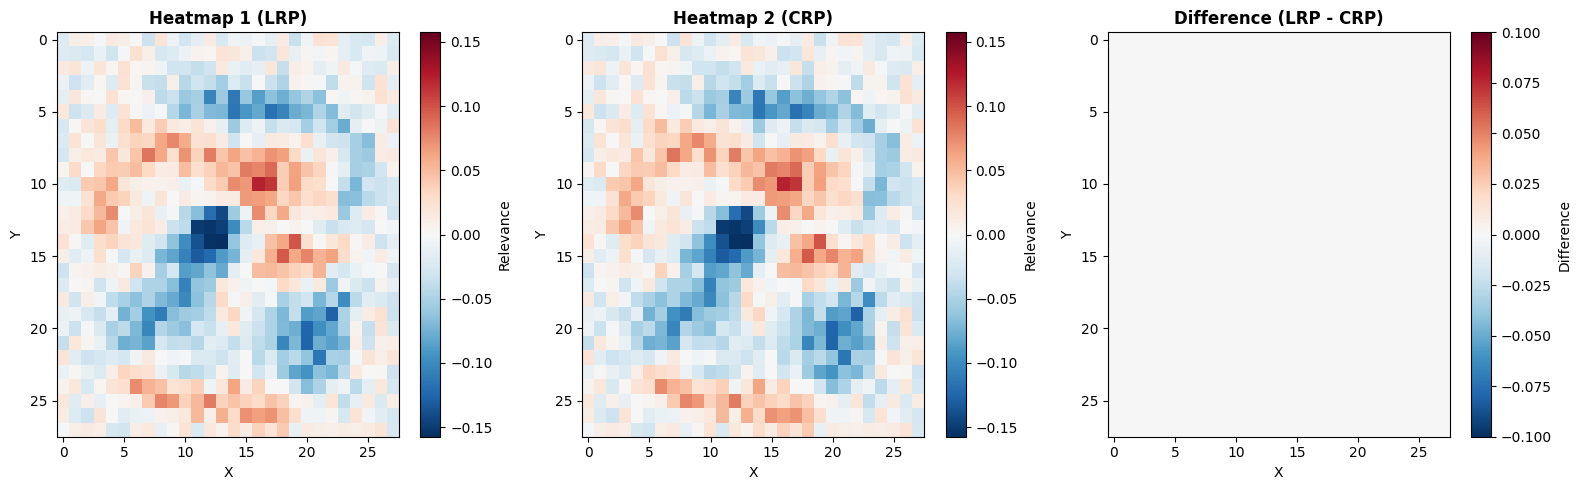


=== Statistics ===
LRP  - Min: -1.574621e-01, Max: 1.215334e-01, Mean: -9.028674e-03, Std: 4.216689e-02
CRP  - Min: -1.574621e-01, Max: 1.215334e-01, Mean: -9.028674e-03, Std: 4.216689e-02
Diff - Min: 0.000000e+00, Max: 0.000000e+00, Mean: 0.000000e+00, Std: 0.000000e+00
L1 Difference: 0.000000e+00
L2 Difference: 0.000000e+00
Max Abs Difference: 0.000000e+00


In [41]:
# linear minst
visualize_heat(vec1, vec2)

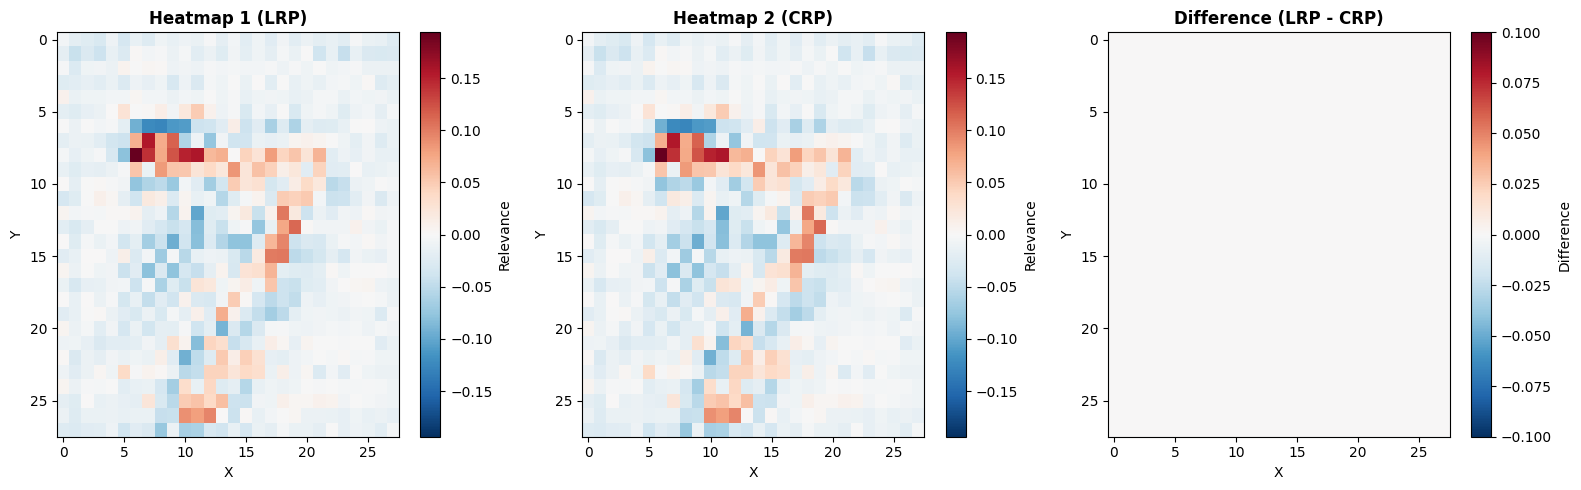


=== Statistics ===
LRP  - Min: -1.258522e-01, Max: 1.938126e-01, Mean: -8.863172e-03, Std: 3.192937e-02
CRP  - Min: -1.258522e-01, Max: 1.938126e-01, Mean: -8.863172e-03, Std: 3.192937e-02
Diff - Min: 0.000000e+00, Max: 0.000000e+00, Mean: 0.000000e+00, Std: 0.000000e+00
L1 Difference: 0.000000e+00
L2 Difference: 0.000000e+00
Max Abs Difference: 0.000000e+00


In [ ]:
# conv mnist
visualize_heat(vec1, vec2)

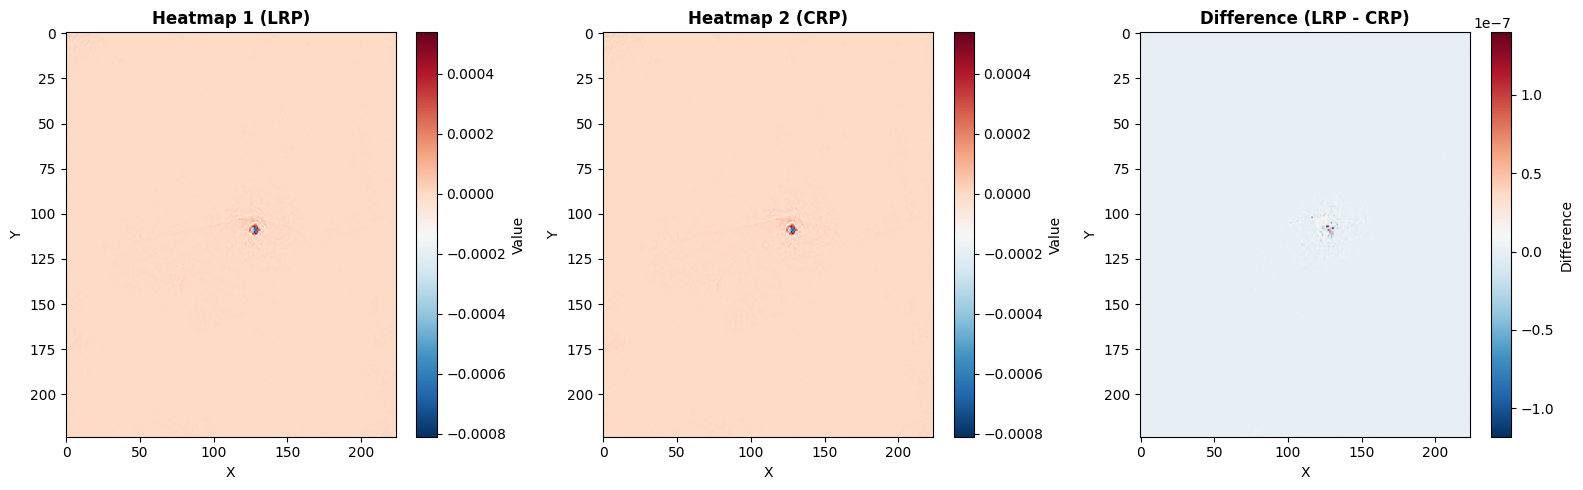


=== Statistics ===
Vec1 - Min: -8.095489e-04, Max: 5.381685e-04, Mean: 4.526232e-08, Std: 1.044007e-05
Vec2 - Min: -8.095698e-04, Max: 5.381971e-04, Mean: 4.525043e-08, Std: 1.044014e-05
Diff - Min: -1.181033e-07, Max: 1.397566e-07, Mean: 1.189476e-11, Std: 1.684678e-09
L1 Difference: 1.134400e-05
L2 Difference: 3.773771e-07
Max Abs Difference: 1.397566e-07


In [ ]:
# vgg, green lizard class
visualize_heat(vec1, vec2)

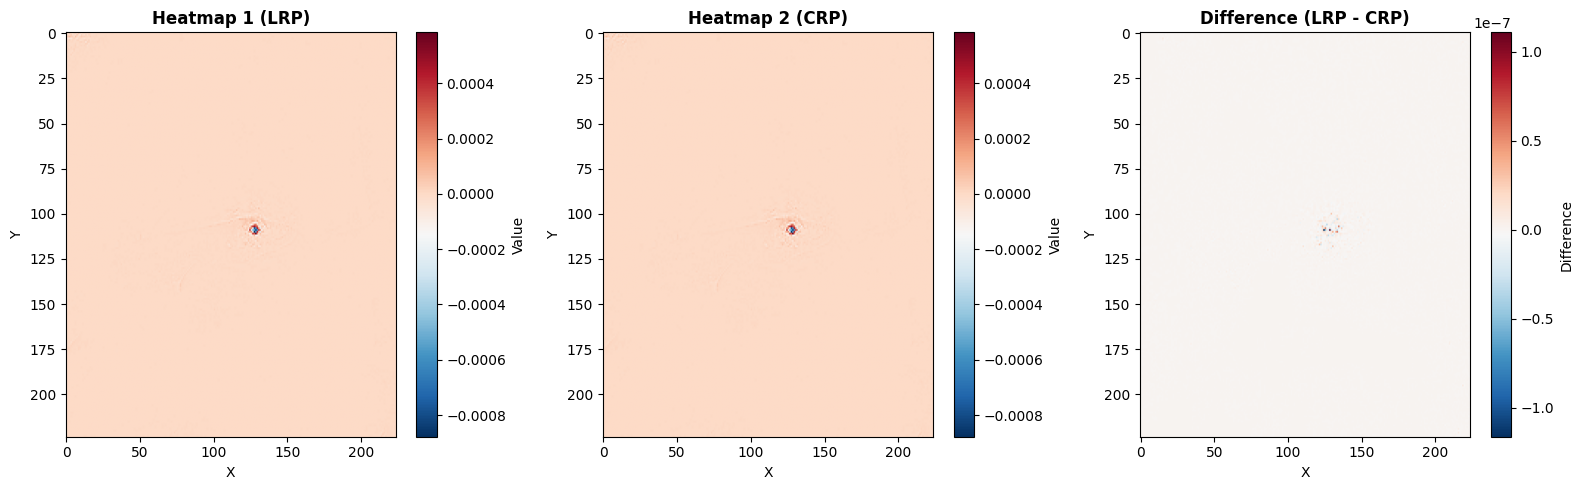


=== Statistics ===
Vec1 - Min: -8.781690e-04, Max: 5.840848e-04, Mean: 4.938821e-08, Std: 1.133156e-05
Vec2 - Min: -8.781630e-04, Max: 5.840799e-04, Mean: 4.938674e-08, Std: 1.133167e-05
Diff - Min: -1.161825e-07, Max: 1.108274e-07, Mean: 1.465816e-12, Std: 1.175483e-09
L1 Difference: 8.535087e-06
L2 Difference: 2.633083e-07
Max Abs Difference: 1.161825e-07


In [25]:
# vgg, chameleon class
visualize_heat(vec1, vec2)

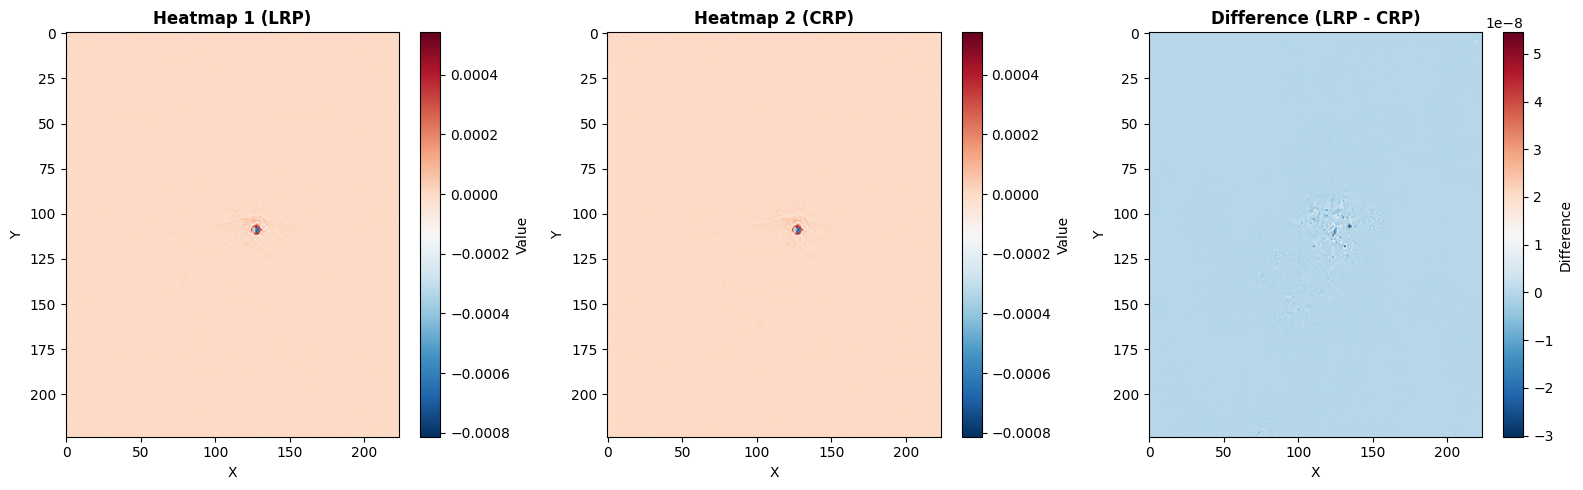


=== Statistics ===
Vec1 - Min: -4.501594e-04, Max: 2.636529e-04, Mean: 1.245679e-08, Std: 3.977577e-06
Vec2 - Min: -4.501595e-04, Max: 2.636529e-04, Mean: 1.245640e-08, Std: 3.977591e-06
Diff - Min: -1.740955e-08, Max: 3.017703e-08, Mean: 3.830748e-13, Std: 2.567360e-10
L1 Difference: 7.075683e-06
L2 Difference: 9.960820e-08
Max Abs Difference: 3.017703e-08


In [32]:
# vgg, chameleon class, .25, .1
visualize_heat(vec1, vec2)

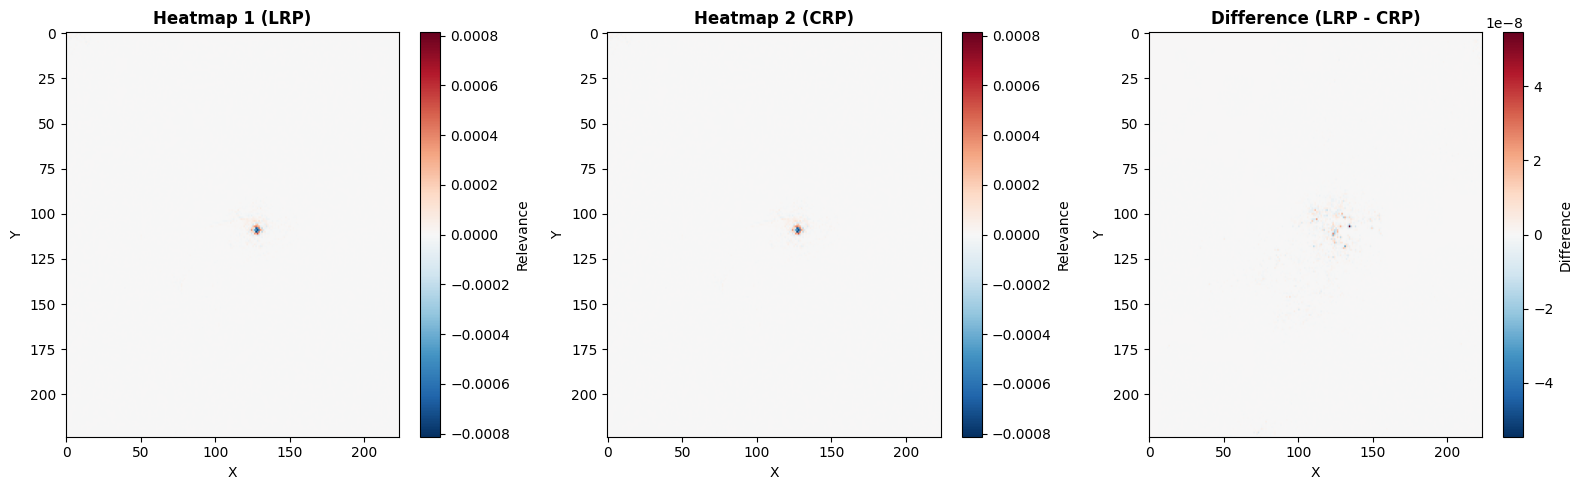


=== Statistics ===
LRP  - Min: -4.501594e-04, Max: 2.636529e-04, Mean: 1.245679e-08, Std: 3.977577e-06
CRP  - Min: -4.501595e-04, Max: 2.636529e-04, Mean: 1.245640e-08, Std: 3.977591e-06
Diff - Min: -1.740955e-08, Max: 3.017703e-08, Mean: 3.830748e-13, Std: 2.567360e-10
L1 Difference: 7.075683e-06
L2 Difference: 9.960820e-08
Max Abs Difference: 3.017703e-08


In [35]:
# vgg, chameleon class, .25, .1
_visualize_heat(vec1, vec2)

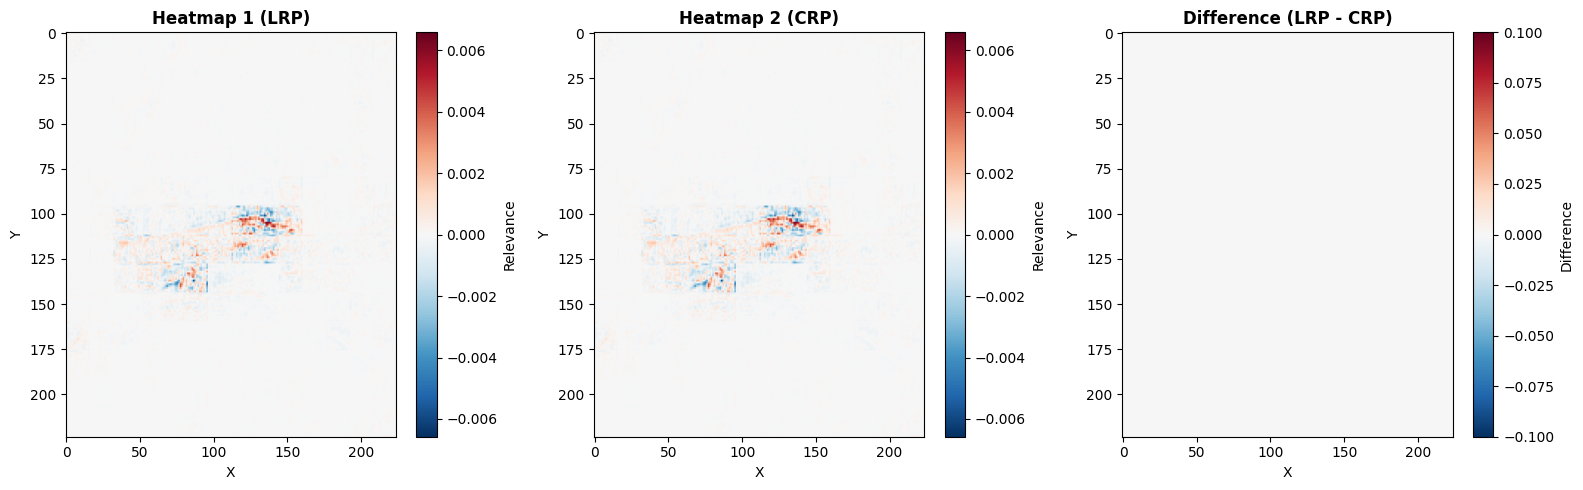


=== Statistics ===
LRP  - Min: -6.082321e-03, Max: 6.576760e-03, Mean: -8.691143e-06, Std: 3.385157e-04
CRP  - Min: -6.082321e-03, Max: 6.576760e-03, Mean: -8.691143e-06, Std: 3.385157e-04
Diff - Min: 0.000000e+00, Max: 0.000000e+00, Mean: 0.000000e+00, Std: 0.000000e+00
L1 Difference: 0.000000e+00
L2 Difference: 0.000000e+00
Max Abs Difference: 0.000000e+00


In [6]:
#vit
visualize_heat(vec1, vec2)